# Charlie Peng

# Compétition 1 : Prédiction de la Qualité de la Bière 🍺

Ce notebook fournit du code de démarrage pour la compétition de prédiction de la qualité de la bière. Pour les instructions complètes, l'énoncé du problème et les critères de notation, veuillez vous référer au fichier **README.md**.

**Résumé rapide** : Vous allez construire un modèle de classification pour prédire la qualité de la bière (scores 1-10) basé sur des propriétés chimiques. Soumettez vos prédictions sur [Kaggle](https://www.kaggle.com/competitions/ift-6390-ift-3395-beer-quality-prediction/).

## Importer les Dépendances

In [1]:
# Importer les bibliothèques requises
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# imports Charlie
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier, NearestCentroid
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

## Charger et Explorer les Données

In [2]:
# Charger les données d'entraînement
train_df = pd.read_csv('data/train.csv', delimiter=';')

print(f"Forme des données d'entraînement : {train_df.shape}")
print(f"Nombre d'échantillons (n) : {train_df.shape[0]}")
print(f"Nombre de caractéristiques (d) : {train_df.shape[1] - 1}")  # Soustraire 1 pour la colonne cible
print(f"Colonnes : {list(train_df.columns)}")
print("\nPremières lignes :")
print(train_df.head())

# Vérifier les types de données et informations de base
print("\nTypes de données et informations :")
print(train_df.info())

####################################################################
###############   À compléter   ####################################
####################################################################

Forme des données d'entraînement : (4469, 15)
Nombre d'échantillons (n) : 4469
Nombre de caractéristiques (d) : 14
Colonnes : ['id', 'beer_style', 'bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength', 'quality']

Premières lignes :
   id beer_style  bitterness_IBU  diacetyl_concentration  lactic_acid  \
0   0       Pale           7.997                   0.446        0.280   
1   1       Pale           6.906                   0.222        0.303   
2   2      Brown           7.183                   0.636        0.071   
3   3       Pale           6.403                   0.242        0.260   
4   4      Brown           7.917                   0.182        0.347   

   final_gravity  sodium  free_CO2  dissolved_oxygen  original_gravity     pH  \
0         10.803   0.052    24.999           157.026             0.995  3.057   
1          6.305   0.

## Exploration Charlie

In [3]:
data = train_df.drop(labels="id", axis=1)
print("Missing data:")
display(data.isna().sum())

Missing data:


beer_style                0
bitterness_IBU            0
diacetyl_concentration    0
lactic_acid               0
final_gravity             0
sodium                    0
free_CO2                  0
dissolved_oxygen          0
original_gravity          0
pH                        0
gypsum_level              0
alcohol_ABV               0
fermentation_strength     0
quality                   0
dtype: int64

In [4]:
print("Statistiques:")
display(data.describe().round(2))
# free_CO2, dissolved_oxygen ont une grande etendue
# lactic acid, sodium ont des valeurs negatives

Statistiques:


,bitterness_IBU,diacetyl_concentration,lactic_acid,final_gravity,sodium,free_CO2,dissolved_oxygen,original_gravity,pH,gypsum_level,alcohol_ABV,fermentation_strength,quality
count,4469.00,4469.00,4469.00,4469.00,4469.00,4469.00,4469.00,4469.00,4469.00,4469.00,4469.00,4469.00,4469.00
mean,7.24,0.34,0.32,5.51,0.06,30.74,116.38,0.99,3.22,0.53,4.99,9.48,5.81
std,1.30,0.16,0.15,4.74,0.03,18.01,56.44,0.01,0.16,0.14,0.56,0.89,0.84
min,3.80,0.06,-0.02,0.60,-0.00,1.00,5.99,0.96,2.72,0.22,3.82,7.43,3.00
25%,6.41,0.23,0.24,1.80,0.04,17.00,78.99,0.99,3.11,0.43,4.52,8.78,5.00
50%,7.00,0.29,0.31,3.12,0.05,29.00,119.00,1.00,3.20,0.51,4.90,9.35,6.00
75%,7.70,0.40,0.39,8.20,0.07,41.98,156.00,1.00,3.32,0.60,5.38,10.11,6.00
max,15.88,1.57,1.67,31.61,0.60,289.00,440.00,1.03,4.01,1.99,7.10,12.65,9.00


Distributions:


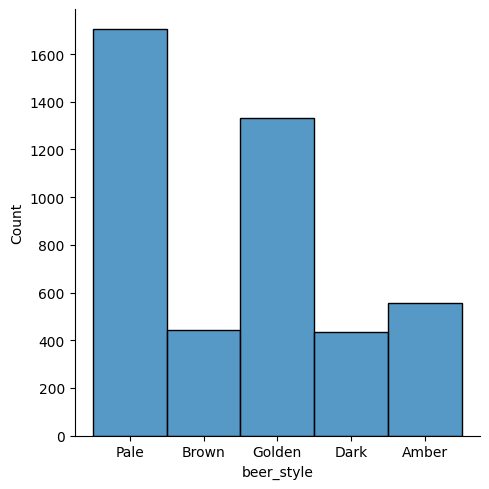

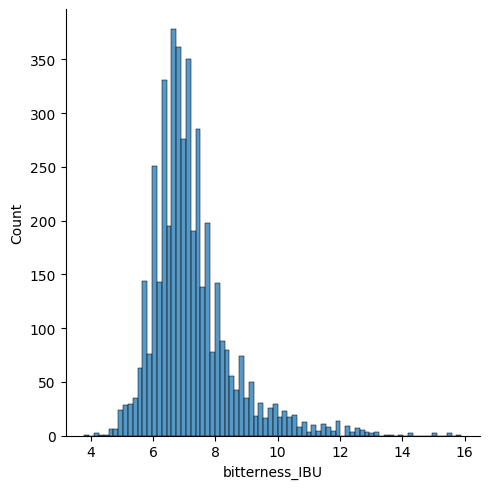

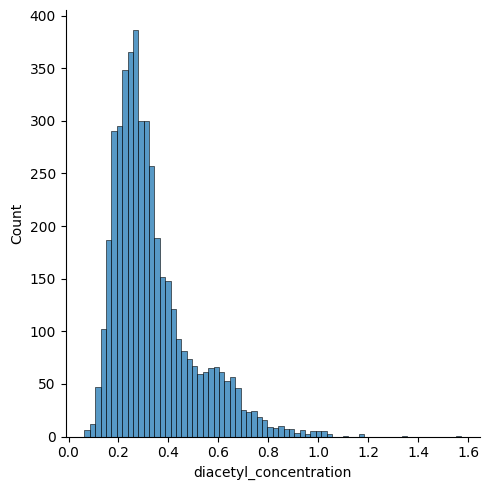

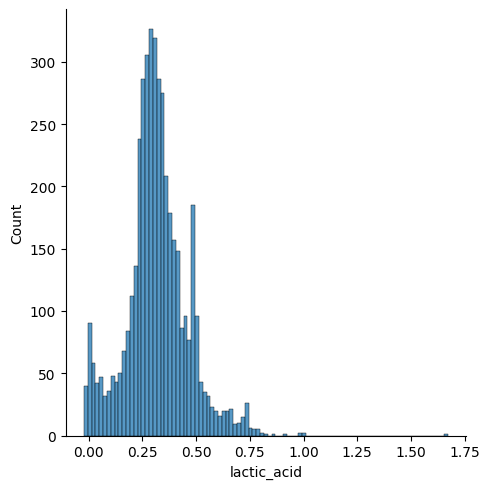

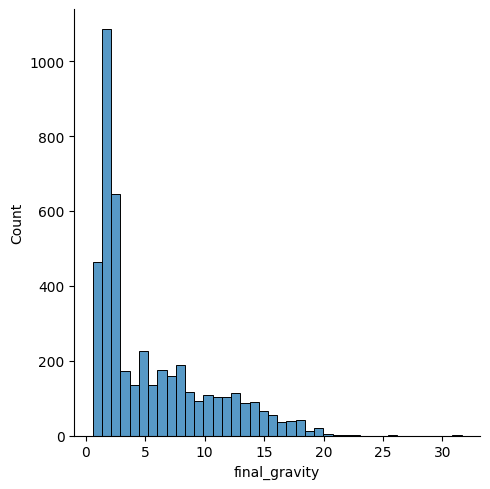

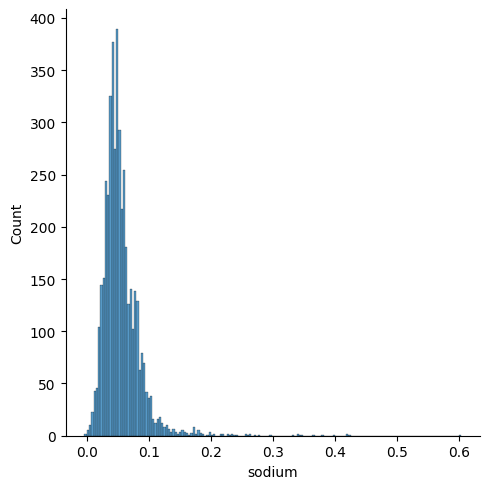

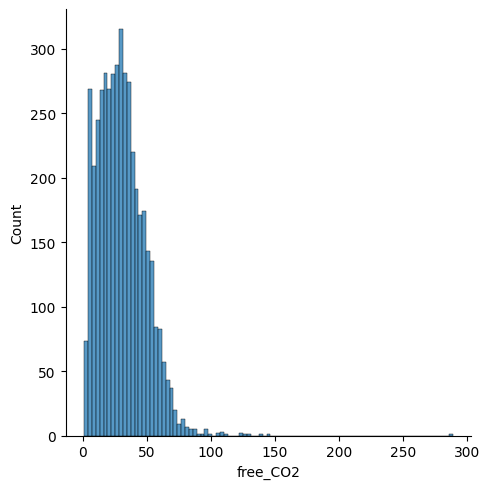

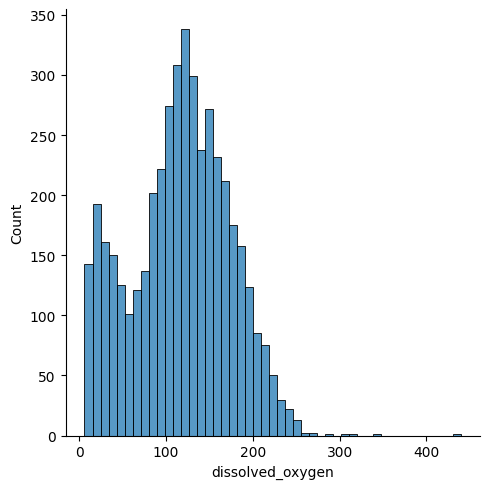

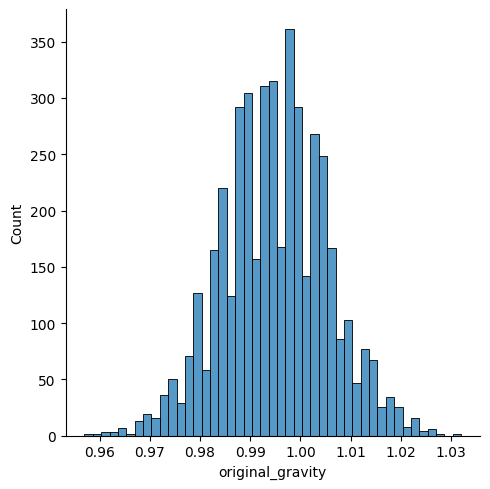

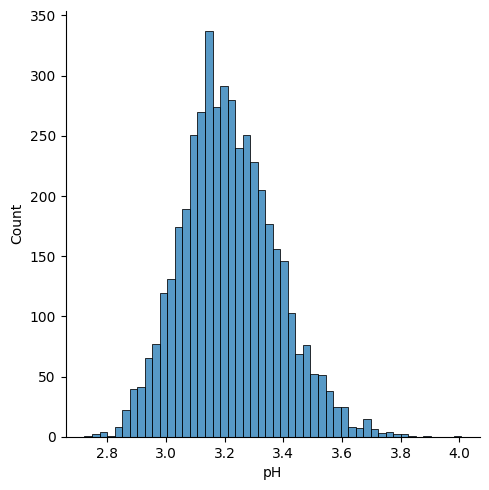

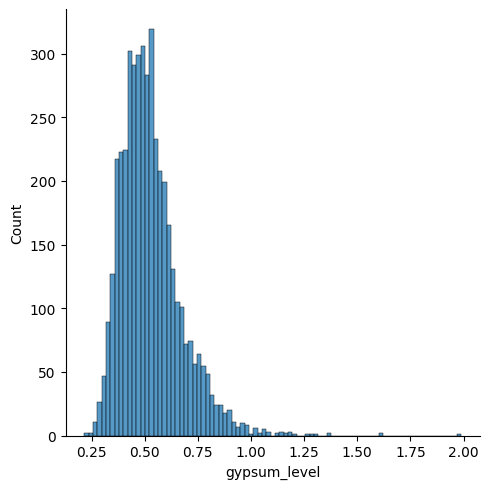

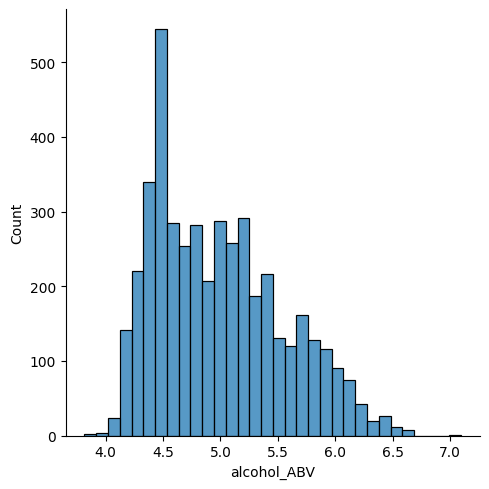

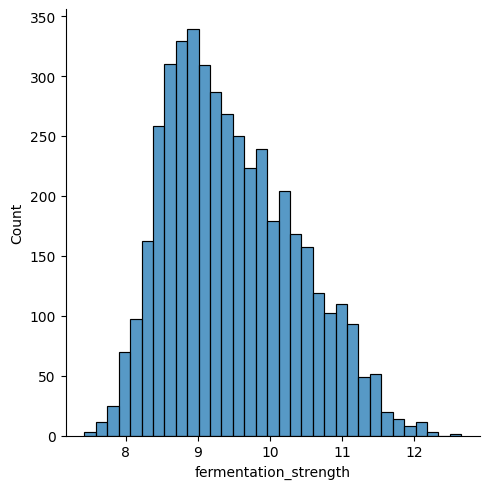

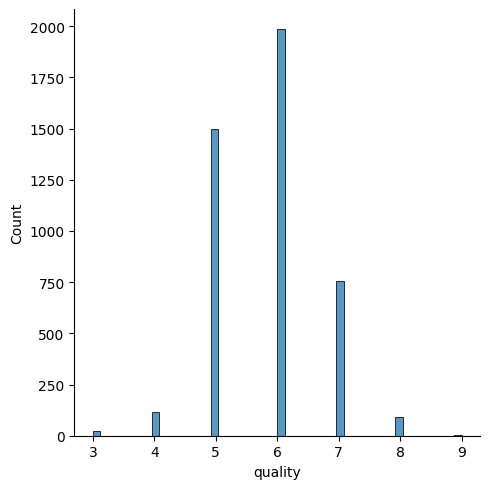

In [5]:
print("Distributions:")
for col in data:
    sns.displot(data, x=col)
    plt.show()

In [6]:
display(data.iloc[:, 1:][(data["lactic_acid"] < 0) | (data["sodium"] < 0)][["lactic_acid", "sodium"]])
# On les valeurs negatives de lactic_acid et de sodium par 0 pour les raisons suivantes:
# 1. L'ensemble de test fourni n'a que 6 bieres dont lactic_acid est negatif et 0 dont sodium est negatif,
# alors que l'ensemble d'entrainement en a beaucoup plus.
# 2. Des quantites negatives d'une substance dans un aliment ne font generalement pas de sens.
# 3. Ces quantites negatives sont proches de 0.
# 4. Donc, ces valeurs sont donc probablement des erreurs de mesure ou d'entrée et elles devraient etre 0.
temp = data.iloc[:, 1:]
temp[temp < 0] = 0
data.iloc[:, 1:] = temp

,lactic_acid,sodium
128,-0.001,0.083
164,-0.005,0.103
211,0.269,-0.001
324,-0.013,0.095
337,-0.021,0.053
427,-0.007,0.067
568,-0.011,0.075
669,-0.004,0.089
941,-0.012,0.062
967,-0.018,0.062


In [7]:
# Outliers
print("Outliers:")
print("diacetyl_concentration")
display(data[data["diacetyl_concentration"] > 1.2])

print("lactic_acid")
display(data[data["lactic_acid"] > 1.15])

print("final_gravity")
display(data[data["final_gravity"] > 31])

print("sodium")
display(data[data["sodium"] > 0.452])

print("free_CO2")
display(data[data["free_CO2"] > 200])

print("dissolved_oxygen")
display(data[data["dissolved_oxygen"] > 400])

print("gypsum_level")
display(data[data["gypsum_level"] > 1.75])

Outliers:
diacetyl_concentration


,beer_style,bitterness_IBU,diacetyl_concentration,lactic_acid,final_gravity,sodium,free_CO2,dissolved_oxygen,original_gravity,pH,gypsum_level,alcohol_ABV,fermentation_strength,quality
62,Brown,7.602,1.572,0.015,2.101,0.139,4.990,9.020,0.993,3.500,0.383,5.196,9.723,3
2723,Brown,8.109,1.337,0.003,1.808,0.082,3.025,12.009,0.985,3.545,0.487,5.190,9.986,5


lactic_acid


,beer_style,bitterness_IBU,diacetyl_concentration,lactic_acid,final_gravity,sodium,free_CO2,dissolved_oxygen,original_gravity,pH,gypsum_level,alcohol_ABV,fermentation_strength,quality
821,Pale,7.391,0.193,1.672,2.085,0.022,33.986,112.976,0.998,3.26,0.563,5.814,10.389,6


final_gravity


...

,beer_style,bitterness_IBU,diacetyl_concentration,lactic_acid,final_gravity,sodium,free_CO2,dissolved_oxygen,original_gravity,pH,gypsum_level,alcohol_ABV,fermentation_strength,quality
363,Pale,6.1,0.253,0.253,2.898,0.053,288.995,440.004,0.989,3.436,0.625,5.006,9.298,3


dissolved_oxygen


,beer_style,bitterness_IBU,diacetyl_concentration,lactic_acid,final_gravity,sodium,free_CO2,dissolved_oxygen,original_gravity,pH,gypsum_level,alcohol_ABV,fermentation_strength,quality
363,Pale,6.1,0.253,0.253,2.898,0.053,288.995,440.004,0.989,3.436,0.625,5.006,9.298,3


gypsum_level


,beer_style,bitterness_IBU,diacetyl_concentration,lactic_acid,final_gravity,sodium,free_CO2,dissolved_oxygen,original_gravity,pH,gypsum_level,alcohol_ABV,fermentation_strength,quality
2073,Dark,8.61,0.477,0.279,1.993,0.123,18.996,132.987,0.987,2.941,1.989,4.673,8.71,5


In [8]:
corr_mat = data.iloc[:, 1:].corr().round(2)
print("Correlation:")
display(corr_mat)
# alcohol_ABV and fermentation_strength ont une correlation tres forte
# alcohol_ABV and fermentation_strength ont la plus grande correlation avec qualite
# free_CO2 and dissolved_oxygen ont une correlation forte

Correlation:


,bitterness_IBU,diacetyl_concentration,lactic_acid,final_gravity,sodium,free_CO2,dissolved_oxygen,original_gravity,pH,gypsum_level,alcohol_ABV,fermentation_strength,quality
bitterness_IBU,1.00,0.21,0.31,-0.13,0.29,-0.29,-0.34,0.12,-0.25,0.30,-0.09,-0.08,-0.07
diacetyl_concentration,0.21,1.00,-0.38,-0.20,0.37,-0.35,-0.41,0.06,0.26,0.23,-0.04,-0.04,-0.26
lactic_acid,0.31,-0.38,1.00,0.14,-0.01,0.13,0.20,0.04,-0.31,0.04,-0.01,-0.01,0.08
final_gravity,-0.13,-0.20,0.14,1.00,-0.14,0.40,0.49,0.17,-0.27,-0.19,-0.37,-0.35,-0.03
sodium,0.29,0.37,-0.01,-0.14,1.00,-0.19,-0.28,0.08,0.05,0.35,-0.23,-0.22,-0.18
free_CO2,-0.29,-0.35,0.13,0.40,-0.19,1.00,0.72,0.02,-0.13,-0.18,-0.18,-0.17,0.05
dissolved_oxygen,-0.34,-0.41,0.20,0.49,-0.28,0.72,1.00,0.03,-0.23,-0.28,-0.27,-0.25,-0.04
original_gravity,0.12,0.06,0.04,0.17,0.08,0.02,0.03,1.00,0.01,0.06,-0.18,-0.17,-0.07
pH,-0.25,0.26,-0.31,-0.27,0.05,-0.13,-0.23,0.01,1.00,0.22,0.12,0.11,0.01
gypsum_level,0.30,0.23,0.04,-0.19,0.35,-0.18,-0.28,0.06,0.22,1.00,0.00,0.00,0.05


Relations avec quality:


quality,3,4,5,6,7,8,9
beer_style,,,,,,,
Amber,0.004,0.013,0.321,0.463,0.187,0.013,0.000
Brown,0.005,0.014,0.471,0.376,0.129,0.007,0.000
Dark,0.011,0.037,0.422,0.420,0.096,0.014,0.000
Golden,0.002,0.029,0.294,0.459,0.186,0.029,0.001
Pale,0.005,0.029,0.313,0.451,0.178,0.022,0.001


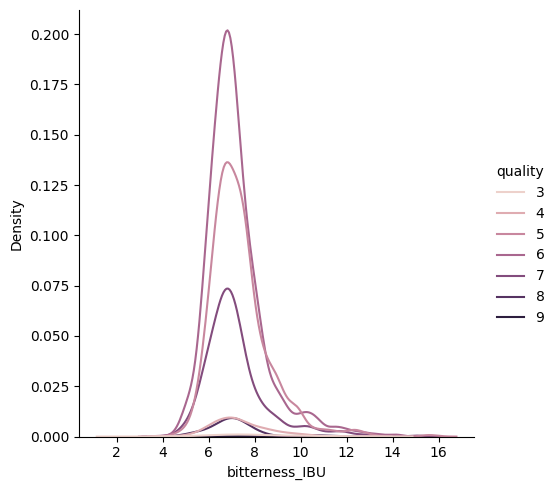

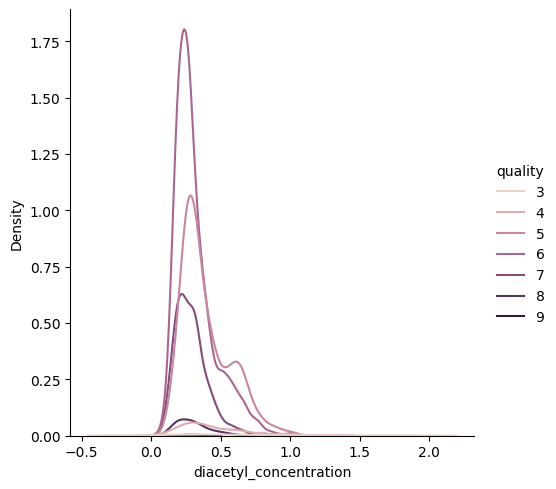

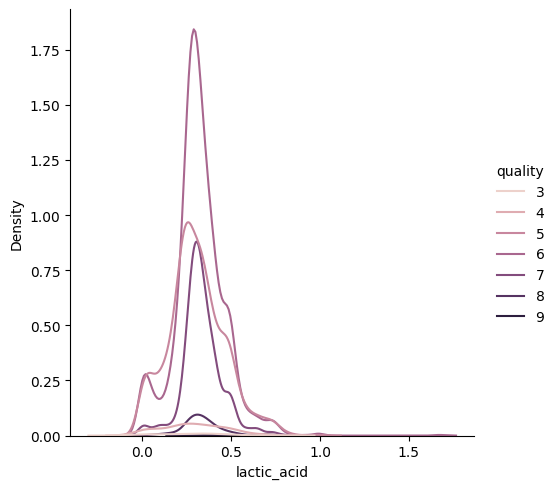

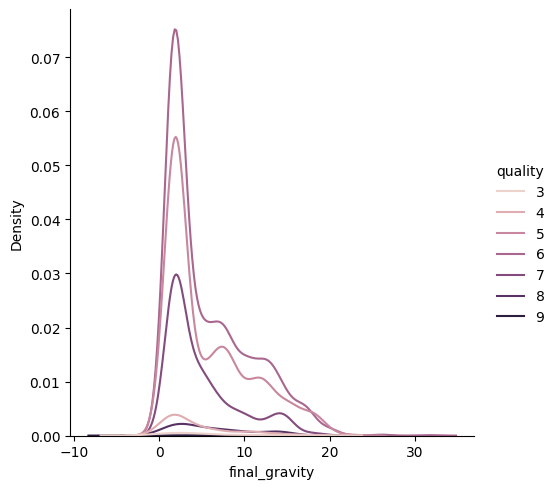

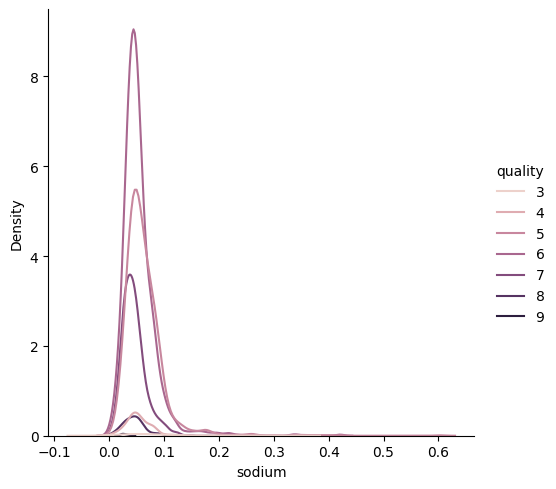

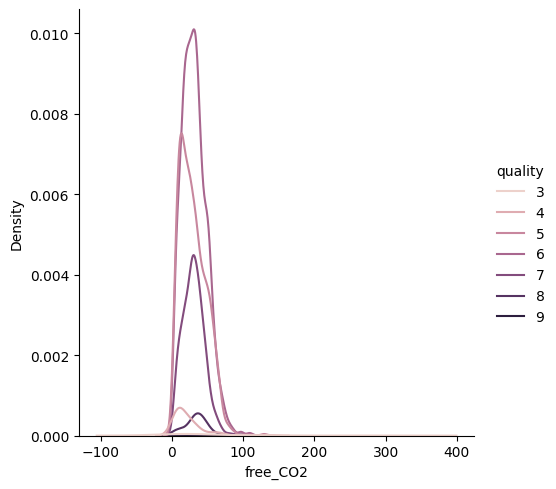

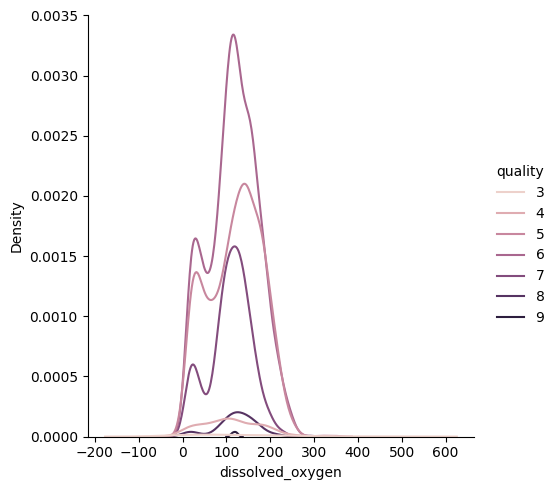

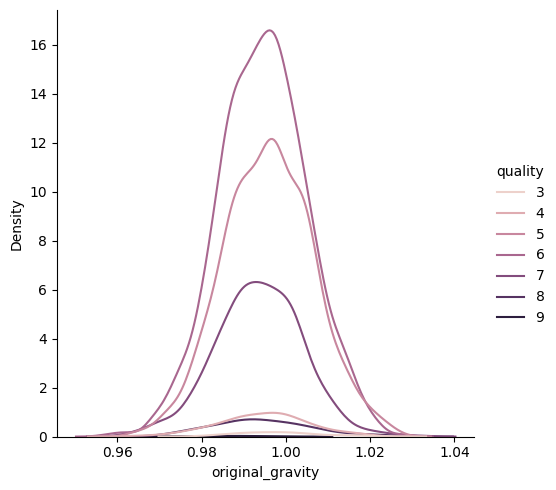

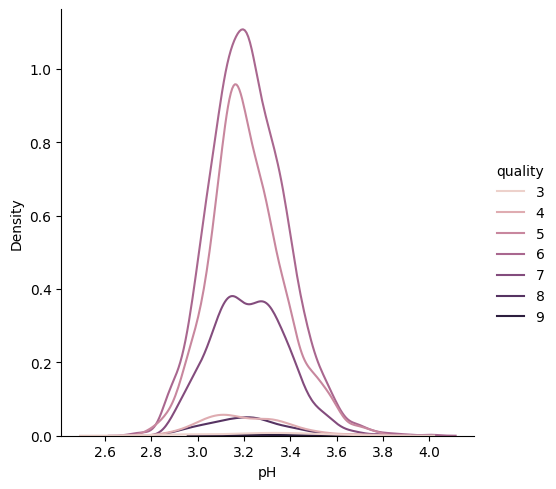

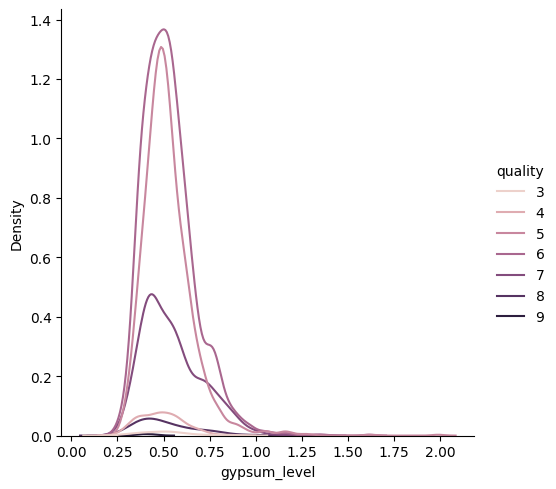

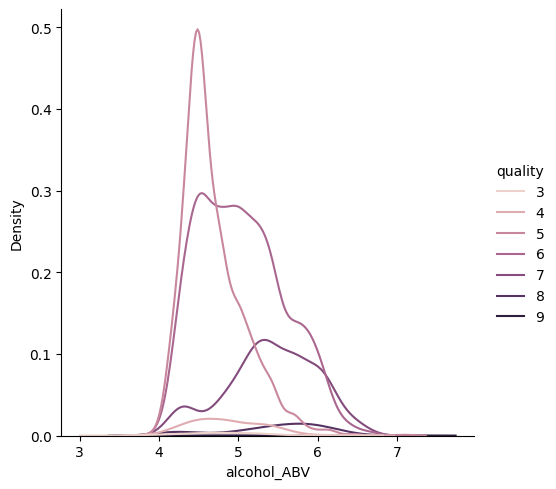

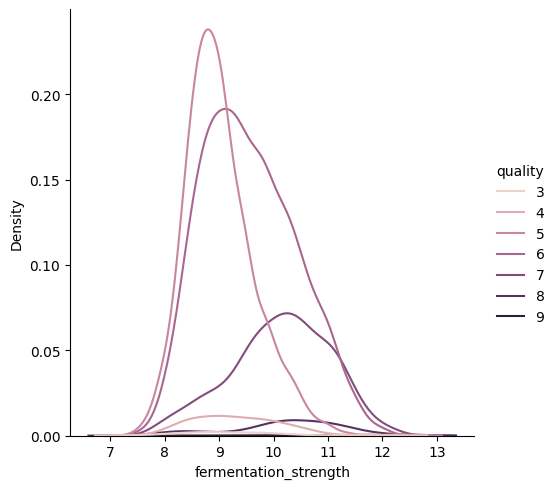

In [9]:
print("Relations avec quality:")
display(pd.crosstab(data["beer_style"], data["quality"], normalize="index").round(3))

for col in data.columns[1:-1]:
    sns.displot(data, x=col, hue="quality", kind="kde")
    plt.show()

Relations entre certaines caracteristiques:


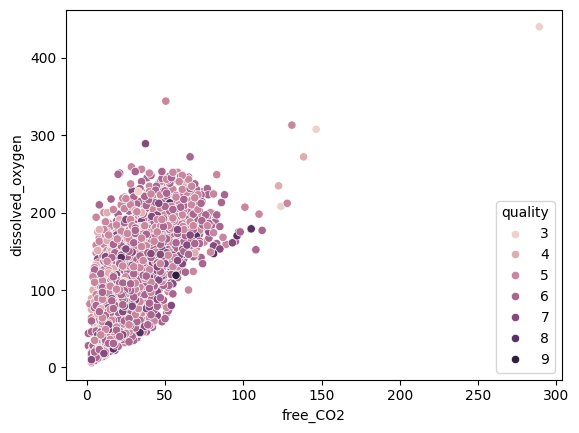

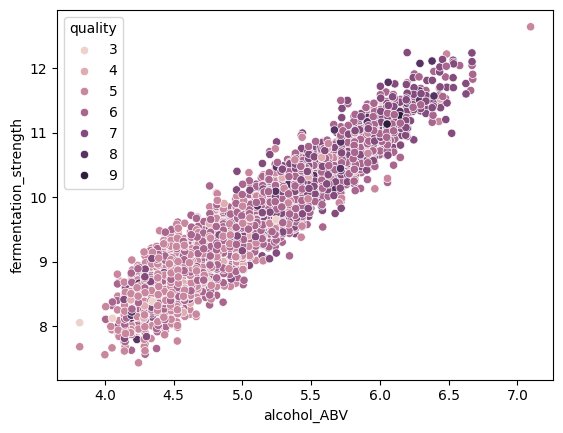

In [10]:
print("Relations entre certaines caracteristiques:")
sns.scatterplot(data, x="free_CO2", y="dissolved_oxygen", hue="quality")
plt.show()

sns.scatterplot(data, x="alcohol_ABV", y="fermentation_strength", hue="quality")
plt.show()

## Prétraitement des Données

Implémentez votre pipeline de prétraitement (voir README.md pour des suggestions).

In [11]:
####################################################################
###############   À compléter   ####################################
####################################################################

# Enlever les valeurs aberrantes. Elles influencent la moyenne et ecart-type qui sont utilises pour standardisation
data_no_outliers = data.query("diacetyl_concentration <= 1.2 & lactic_acid <= 1.15 & \
    final_gravity <= 31 & sodium <= 0.452 & free_CO2 <= 200 & dissolved_oxygen <= 400 & gypsum_level <= 1.75") \
    .reset_index().drop("index", axis=1)

# Standardiser
scaler = StandardScaler()
data_cont_feat = data_no_outliers.iloc[:,1:-1]
scaler.fit(data_cont_feat)
temp_scaled = scaler.transform(data_cont_feat)

data_scaled = data_no_outliers.copy()
data_scaled.iloc[:, 1:-1] = temp_scaled
print("Donnees scaled:")
display(data_scaled)

Donnees scaled:


,beer_style,bitterness_IBU,diacetyl_concentration,lactic_acid,final_gravity,sodium,free_CO2,dissolved_oxygen,original_gravity,pH,gypsum_level,alcohol_ABV,fermentation_strength,quality
0,Pale,0.587567,0.665605,-0.264179,1.120723,-0.104041,-0.324342,0.723518,0.013645,-0.992861,-0.438905,0.802618,0.074016,7
1,Pale,-0.253679,-0.716754,-0.103727,0.169175,-0.651373,0.584885,0.260373,1.630851,-0.831674,-0.368117,0.268773,0.412517,6
2,Brown,-0.040090,1.838142,-1.722203,-0.636827,0.747365,-0.779182,-0.575612,1.725981,1.809309,0.120323,-0.657867,-0.793533,5
3,Pale,-0.641531,-0.593329,-0.403703,-0.846049,-0.377707,0.244138,-0.202043,-0.081485,-0.496901,-1.557361,1.647128,1.148925,6
4,Brown,0.525881,-0.963604,0.203226,-0.805009,-0.073633,-1.346923,-1.803241,0.679553,0.674803,1.960819,1.227551,0.301552,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4457,Golden,0.432581,-0.975946,0.977583,1.712003,0.260848,0.415592,0.028951,0.394164,-0.441106,-0.198225,-0.397194,-0.595140,6
4458,Amber,-0.253679,0.412584,-1.185037,-0.657982,0.808180,-0.550767,-1.358793,0.964943,1.251355,0.707866,-0.641798,-0.068334,6
4459,Golden,-0.717096,0.134878,-0.738560,-0.739006,-0.195263,0.983219,1.328330,0.203904,-0.255121,-0.063727,-0.731070,-0.252155,5
4460,Pale,-0.716325,-1.358564,0.293916,-0.721235,-0.134448,0.925575,0.527198,0.869813,0.265636,1.479459,0.784764,0.887764,7


In [12]:
# Encoder caracéristiques catégorielles
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
beer_style_encoded = encoder.fit_transform(data_scaled[["beer_style"]])
beer_style_df = pd.DataFrame(beer_style_encoded, columns=encoder.get_feature_names_out(["beer_style"]))
data_scaled_cont = data_scaled.drop("beer_style", axis=1)
data_scaled_enc = pd.concat([beer_style_df, data_scaled_cont], axis=1)
display(data_scaled_enc)

,beer_style_Amber,beer_style_Brown,beer_style_Dark,beer_style_Golden,beer_style_Pale,bitterness_IBU,diacetyl_concentration,lactic_acid,final_gravity,sodium,free_CO2,dissolved_oxygen,original_gravity,pH,gypsum_level,alcohol_ABV,fermentation_strength,quality
0,0.0,0.0,0.0,0.0,1.0,0.587567,0.665605,-0.264179,1.120723,-0.104041,-0.324342,0.723518,0.013645,-0.992861,-0.438905,0.802618,0.074016,7
1,0.0,0.0,0.0,0.0,1.0,-0.253679,-0.716754,-0.103727,0.169175,-0.651373,0.584885,0.260373,1.630851,-0.831674,-0.368117,0.268773,0.412517,6
2,0.0,1.0,0.0,0.0,0.0,-0.040090,1.838142,-1.722203,-0.636827,0.747365,-0.779182,-0.575612,1.725981,1.809309,0.120323,-0.657867,-0.793533,5
3,0.0,0.0,0.0,0.0,1.0,-0.641531,-0.593329,-0.403703,-0.846049,-0.377707,0.244138,-0.202043,-0.081485,-0.496901,-1.557361,1.647128,1.148925,6
4,0.0,1.0,0.0,0.0,0.0,0.525881,-0.963604,0.203226,-0.805009,-0.073633,-1.346923,-1.803241,0.679553,0.674803,1.960819,1.227551,0.301552,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4457,0.0,0.0,0.0,1.0,0.0,0.432581,-0.975946,0.977583,1.712003,0.260848,0.415592,0.028951,0.394164,-0.441106,-0.198225,-0.397194,-0.595140,6
4458,1.0,0.0,0.0,0.0,0.0,-0.253679,0.412584,-1.185037,-0.657982,0.808180,-0.550767,-1.358793,0.964943,1.251355,0.707866,-0.641798,-0.068334,6
4459,0.0,0.0,0.0,1.0,0.0,-0.717096,0.134878,-0.738560,-0.739006,-0.195263,0.983219,1.328330,0.203904,-0.255121,-0.063727,-0.731070,-0.252155,5
4460,0.0,0.0,0.0,0.0,1.0,-0.716325,-1.358564,0.293916,-0.721235,-0.134448,0.925575,0.527198,0.869813,0.265636,1.479459,0.784764,0.887764,7


In [13]:
# Calculer score mutual information pour selectionner meilleures caracteristiques
RANDOM_SEED = 259
features = data_scaled_enc.iloc[:, :-1]
discrete_mask = [0,1,2,3,4]
target = data_scaled_enc["quality"]
mi_scores = mutual_info_classif(features, target, discrete_features=discrete_mask, random_state=RANDOM_SEED)
feat_mi_scores = pd.DataFrame.from_dict({"feature": features.columns, "mi_score": mi_scores})
feat_mi_scores_sorted = feat_mi_scores.sort_values(by="mi_score", ascending=False)
print("Scores MI triés:")
display(feat_mi_scores_sorted)

Scores MI triés:


,feature,mi_score
15,alcohol_ABV,0.153691
16,fermentation_strength,0.118209
8,final_gravity,0.058581
11,dissolved_oxygen,0.056754
7,lactic_acid,0.042679
6,diacetyl_concentration,0.041132
10,free_CO2,0.039827
14,gypsum_level,0.032100
9,sodium,0.028171
5,bitterness_IBU,0.024572


In [14]:
# On prend choisit les 7 meilleurs caracteristiqes excluant fermentation_strength, 
# car il est tres fortement correle avec alcohol_ABV (vu dans la partie exploration)
# et son mi_score est inferieur a celui de alcohol_ABV 
selected_feat = list(feat_mi_scores_sorted.query("feature != 'fermentation_strength'")["feature"][:7])
print("Features selected:")
print(selected_feat)
data = data_scaled_enc[selected_feat + ["quality"]]
display(data)

Features selected:
['alcohol_ABV', 'final_gravity', 'dissolved_oxygen', 'lactic_acid', 'diacetyl_concentration', 'free_CO2', 'gypsum_level']


,alcohol_ABV,final_gravity,dissolved_oxygen,lactic_acid,diacetyl_concentration,free_CO2,gypsum_level,quality
0,0.802618,1.120723,0.723518,-0.264179,0.665605,-0.324342,-0.438905,7
1,0.268773,0.169175,0.260373,-0.103727,-0.716754,0.584885,-0.368117,6
2,-0.657867,-0.636827,-0.575612,-1.722203,1.838142,-0.779182,0.120323,5
3,1.647128,-0.846049,-0.202043,-0.403703,-0.593329,0.244138,-1.557361,6
4,1.227551,-0.805009,-1.803241,0.203226,-0.963604,-1.346923,1.960819,7
...,...,...,...,...,...,...,...,...
4457,-0.397194,1.712003,0.028951,0.977583,-0.975946,0.415592,-0.198225,6
4458,-0.641798,-0.657982,-1.358793,-1.185037,0.412584,-0.550767,0.707866,6
4459,-0.731070,-0.739006,1.328330,-0.738560,0.134878,0.983219,-0.063727,5
4460,0.784764,-0.721235,0.527198,0.293916,-1.358564,0.925575,1.479459,7


## Préparer les Données d'Entraînement et de Validation

Divisez vos données en ensembles d'entraînement et de validation.

In [15]:
####################################################################
###############   À compléter   ####################################
####################################################################
X = data.iloc[:, :-1]
y = data["quality"]
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.8, random_state=RANDOM_SEED)

## Entraîner les Modèles

Entraînez et comparez plusieurs modèles d'apprentissage automatique.

KNN


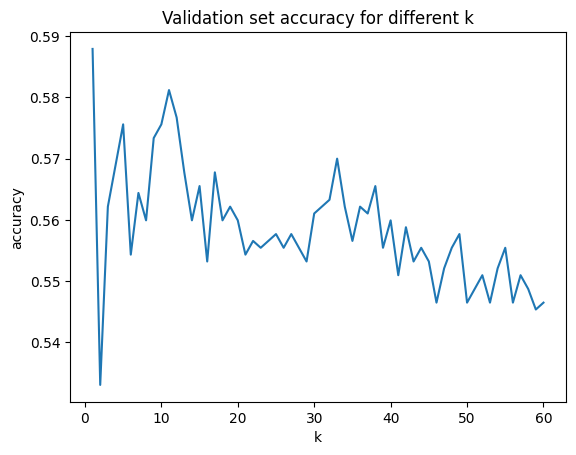

Optimal k: 1
Optimal accuracy: 0.5879059350503919


In [16]:
####################################################################
###############   À compléter   ####################################
####################################################################
# KNN optimal
# Evaluer accuracy pour differentes valeurs d'hyperparametre
print("KNN")
accs = []
hp_range = np.arange(1, 61, 1)
opt_acc = 0
for hp in hp_range:
    cur_classifier = KNeighborsClassifier(n_neighbors=hp)
    cur_classifier.fit(X_train, y_train)
    y_pred = cur_classifier.predict(X_val)
    cur_acc = accuracy_score(y_val, y_pred)
    accs.append(cur_acc)
    if cur_acc >= opt_acc:
        opt_hp = hp
        opt_acc = cur_acc
        opt_classifier = cur_classifier

fig, ax = plt.subplots()
ax.plot(hp_range, accs)
ax.set(xlabel='k', ylabel='accuracy',
       title='Validation set accuracy for different k')
plt.show()

print(f"Optimal k: {opt_hp}")
print(f"Optimal accuracy: {opt_acc}")

knn_classifier = opt_classifier

Parzen


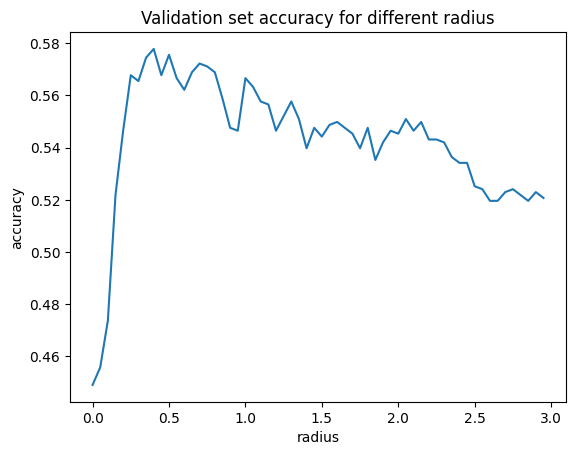

Optimal radius: 0.4
Optimal accuracy: 0.5778275475923852


In [17]:
# Parzen optimal
# Evaluer accuracy pour differentes valeurs d'hyperparametre
print("Parzen")
accs = []
hp_range = np.arange(0, 3, 0.05)
opt_acc = 0
for hp in hp_range:
    cur_classifier = RadiusNeighborsClassifier(radius=hp, outlier_label="most_frequent")
    cur_classifier.fit(X_train, y_train)
    y_pred = cur_classifier.predict(X_val)
    cur_acc = accuracy_score(y_val, y_pred)
    accs.append(cur_acc)
    if cur_acc >= opt_acc:
        opt_hp = hp
        opt_acc = cur_acc
        opt_classifier = cur_classifier

fig, ax = plt.subplots()
ax.plot(hp_range, accs)
ax.set(xlabel='radius', ylabel='accuracy',
       title='Validation set accuracy for different radius')
plt.show()

print(f"Optimal radius: {opt_hp}")
print(f"Optimal accuracy: {opt_acc}")

parzen_classifier = opt_classifier

In [18]:
# Gaussian Naive Bayes
print("Gaussian Naive Bayes")
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_val)
acc = accuracy_score(y_val, y_pred)
print(f"Accuracy: {acc}")

Gaussian Naive Bayes
Accuracy: 0.48936170212765956


In [19]:
# Linear Discriminant Analysis
print("Linear Discriminant Analysis")
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_val)
acc = accuracy_score(y_val, y_pred)
print(f"Accuracy: {acc}")

Linear Discriminant Analysis
Accuracy: 0.5431131019036954


SVM


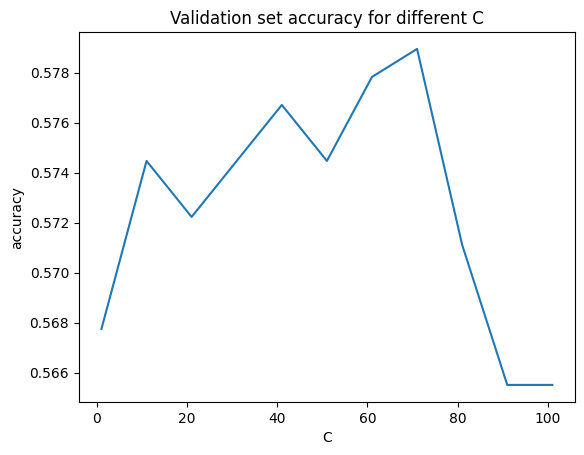

Optimal C: 71
Optimal accuracy: 0.5789473684210527


In [20]:
# SVM
# Evaluer accuracy pour differentes valeurs d'hyperparametre
print("SVM")
accs = []
hp_range = np.arange(1, 102, 10)
opt_acc = 0
for hp in hp_range:
    cur_classifier = SVC(C=hp)
    cur_classifier.fit(X_train, y_train)
    y_pred = cur_classifier.predict(X_val)
    cur_acc = accuracy_score(y_val, y_pred)
    accs.append(cur_acc)
    if cur_acc >= opt_acc:
        opt_hp = hp
        opt_acc = cur_acc
        opt_classifier = cur_classifier

fig, ax = plt.subplots()
ax.plot(hp_range, accs)
ax.set(xlabel='C', ylabel='accuracy',
       title='Validation set accuracy for different C')
plt.show()

print(f"Optimal C: {opt_hp}")
print(f"Optimal accuracy: {opt_acc}")

SVM_classifier = opt_classifier

## Évaluer les Modèles

Analysez la performance de votre meilleur modèle (voir README.md pour les directives d'évaluation).

In [21]:
####################################################################
###############   À compléter   ####################################
####################################################################
# On choisit le classifieur ayant la plus grande accuracy
opt_model = knn_classifier

def confusion_matrix_df(y_true, y_pred, normalize=False):
    quality_range = np.arange(3,9+1)
    norm = "true" if normalize else None
    cf = confusion_matrix(y_true, y_pred, normalize=norm)
    return pd.DataFrame(cf, index=quality_range, columns=quality_range)   

# Predictions ensemble d'entrainement
y_pred = opt_model.predict(X_train)
print("Performance sur l'ensemble d'entraînement")
print("Metriques de performance:\n")
print(classification_report(y_train, y_pred))
print("Matrice de confusion:")
display(confusion_matrix_df(y_train, y_pred))

print("\n------------------------------------------------------\n")

# Predictions ensemble de validation
y_pred = opt_model.predict(X_val)
print("Performance sur l'ensemble de validation")
print("Metriques de performance:\n")
print(classification_report(y_val, y_pred))
print()
print("Matrice de confusion:")
display(confusion_matrix_df(y_val, y_pred))
print()
print("Matrice de confusion normalisée:")
display(confusion_matrix_df(y_val, y_pred, normalize=True).round(2))

Performance sur l'ensemble d'entraînement
Metriques de performance:

              precision    recall  f1-score   support

           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00        88
           5       1.00      1.00      1.00      1201
           6       1.00      1.00      1.00      1582
           7       1.00      1.00      1.00       608
           8       1.00      1.00      1.00        72
           9       1.00      1.00      1.00         2

    accuracy                           1.00      3569
   macro avg       1.00      1.00      1.00      3569
weighted avg       1.00      1.00      1.00      3569

Matrice de confusion:


,3,4,5,6,7,8,9
3,16,0,0,0,0,0,0
4,0,88,0,0,0,0,0
5,0,0,1201,0,0,0,0
6,0,0,0,1582,0,0,0
7,0,0,0,0,608,0,0
8,0,0,0,0,0,72,0
9,0,0,0,0,0,0,2



------------------------------------------------------

Performance sur l'ensemble de validation
Metriques de performance:

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.14      0.11      0.12        28
           5       0.62      0.64      0.63       292
           6       0.62      0.61      0.61       401
           7       0.54      0.56      0.55       147
           8       0.43      0.43      0.43        21
           9       0.00      0.00      0.00         1

    accuracy                           0.59       893
   macro avg       0.33      0.34      0.33       893
weighted avg       0.58      0.59      0.59       893


Matrice de confusion:


C:\Users\charlie\miniconda3\envs\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\charlie\miniconda3\envs\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\charlie\miniconda3\envs\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

,3,4,5,6,7,8,9
3,0,0,2,1,0,0,0
4,0,3,16,5,4,0,0
5,0,10,187,82,12,1,0
6,1,9,90,243,51,7,0
7,0,0,8,52,83,4,0
8,0,0,1,7,4,9,0
9,0,0,0,0,1,0,0



Matrice de confusion normalisée:


,3,4,5,6,7,8,9
3,0.0,0.00,0.67,0.33,0.00,0.00,0.0
4,0.0,0.11,0.57,0.18,0.14,0.00,0.0
5,0.0,0.03,0.64,0.28,0.04,0.00,0.0
6,0.0,0.02,0.22,0.61,0.13,0.02,0.0
7,0.0,0.00,0.05,0.35,0.56,0.03,0.0
8,0.0,0.00,0.05,0.33,0.19,0.43,0.0
9,0.0,0.00,0.00,0.00,1.00,0.00,0.0


## Générer les Prédictions pour la Soumission Kaggle

Créez un fichier CSV avec les colonnes : `id` et `quality` (voir README.md pour les détails du format).

In [22]:
####################################################################
###############   À compléter   ####################################
####################################################################
test_df = pd.read_csv('data/test.csv', delimiter=';')

# Standardiser
scaler = StandardScaler()
train_data_feat = data_cont_feat[selected_feat]
scaler.fit(train_data_feat)
X_test = test_df[selected_feat].copy()
X_test.iloc[:,:] = scaler.transform(test_df[selected_feat])

print("Donnees standardisees")
display(X_test)

# Predire
y_pred = opt_model.predict(X_test)

ids = np.arange(0, test_df.shape[0])
res_dict = {"id": ids, "quality": y_pred}
res = pd.DataFrame(res_dict)
res.to_csv("submission.csv", index=False)

Donnees standardisees


,alcohol_ABV,final_gravity,dissolved_oxygen,lactic_acid,diacetyl_concentration,free_CO2,gypsum_level
0,0.622289,0.570061,0.847555,1.277559,0.498982,0.073310,0.403476
1,-1.325620,0.949791,0.171562,1.793798,-0.710583,0.186779,-0.608797
2,2.163119,-0.694792,0.047134,-0.445560,0.054652,0.016121,-0.247777
3,2.486282,-0.740909,0.224969,-1.059465,1.091421,-0.438492,1.670587
4,2.148835,-0.149841,-0.700200,3.307631,1.165476,-0.437810,1.748454
...,...,...,...,...,...,...,...
506,0.013456,-0.717639,0.989738,0.286940,-0.081116,-0.267039,-0.304407
507,-0.570381,-0.782796,-1.518892,-0.724608,1.776430,-0.949954,0.941467
508,1.738185,0.123692,-0.718240,0.838059,1.103764,-1.404169,-0.226540
509,-0.904257,1.202804,1.755075,1.270583,-0.223054,2.120576,0.545053


---
Bonne chance pour la compétition ! 🍺
